# Código Exploratorio de los archivos .fna

## 1. Importamos las librerías necesarias

In [6]:
import sys
print(sys.executable)

/opt/conda/envs/TDA/bin/python


In [7]:
pip install ripser

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [9]:
from pathlib import Path
import sys

# carpeta raíz del proyecto
ROOT = Path.cwd().parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

In [10]:

import numpy as np
from KmerTopology.kmer_topology import KmerTopology, KmerHomology
from Bio import SeqIO
#Libreria para leer carpetas
from pathlib import Path
import statistics
import matplotlib.pyplot as plt

## 2. Distrubución del número de contigs en los archivos .fna

In [11]:
"""
Este es un análisis exploratorio para ver cuantos de nuestros archivos .fna están
divididos en contigs
"""
carpeta = Path("/files2/generic-amr/data/genomes")
lista_contigs = []

In [7]:
for archivo in carpeta.glob("*.fna"):
    contigs = list(SeqIO.parse(archivo, "fasta"))
    lista_contigs.append(len(contigs))
print(f"Promedio: {statistics.mean(lista_contigs)}")
print(f"Varianza: {statistics.variance(lista_contigs)}")

Promedio: 201.2184686912652
Varianza: 1390660.4049968487


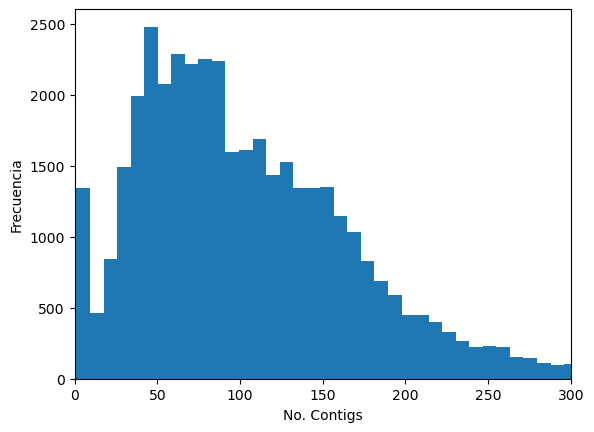

In [16]:
plt.hist(lista_contigs, bins = 4000)
plt.xlabel("No. Contigs")
plt.xlim(0, 300)
plt.ylabel("Frecuencia")
plt.show()


## 3. Filtramos los archivos completos (con un sólo contig)

In [12]:
import pandas as pd

In [13]:
nombres = []
for archivo in carpeta.glob("*.fna"):
    secuencia = list(SeqIO.parse(archivo, "fasta"))
    # Si solo tiene un contig lo guardamos
    if len(secuencia) == 1:
        nombres.append(archivo.name)
print(f"{len(nombres)} secuencias encontradas completas")




77 secuencias encontradas completas


In [14]:
df = pd.DataFrame(nombres, columns = ["Sec. Completas"])
df.to_csv("../data/processed/secuencias_completas.csv")

In [15]:
pwd

'/home/jupyter-gerardorocha/proyectos/KmerTopology/notebooks'

In [16]:
print(df)

         Sec. Completas
0   GCA_037951045.1.fna
1   GCA_003073795.1.fna
2   GCA_039699835.1.fna
3   GCA_003074115.1.fna
4   GCA_003288335.1.fna
..                  ...
72  GCA_034425135.2.fna
73  GCA_009428985.1.fna
74  GCA_003073615.1.fna
75  GCA_001095405.3.fna
76  GCA_002796425.1.fna

[77 rows x 1 columns]


In [17]:
 #Diccionario de Secuencias
secuences = {}

for nombre in df["Sec. Completas"]:
    ruta = carpeta / nombre
    secuence = list(SeqIO.parse(ruta, "fasta"))
    print(nombre, len(secuence[0].seq))

GCA_037951045.1.fna 2913135
GCA_003073795.1.fna 7267567
GCA_039699835.1.fna 2782991
GCA_003074115.1.fna 6776714
GCA_003288335.1.fna 6303875
GCA_037199675.2.fna 2818489
GCA_032629165.2.fna 1912433
GCA_037046245.2.fna 2919719
GCA_002968585.1.fna 6747010
GCA_037809465.1.fna 2795256
GCA_000775955.1.fna 5118878
GCA_037202005.1.fna 2779773
GCA_030253475.1.fna 7082165
GCA_000807395.2.fna 5344430
GCA_040256175.1.fna 4719089
GCA_000626615.3.fna 2810186
GCA_021496255.1.fna 5023197
GCA_009455505.1.fna 4092125
GCA_000368185.1.fna 3953145
GCA_003071645.1.fna 4849791
GCA_003194245.1.fna 6859232
GCA_003193745.1.fna 2963657
GCA_002948925.1.fna 3871930
GCA_020540925.1.fna 4918254
GCA_003073735.1.fna 7125975
GCA_013343375.1.fna 6506945
GCA_003324295.1.fna 7079305
GCA_040114725.1.fna 2744522
GCA_041519645.1.fna 6413472
GCA_039134645.1.fna 2739862
GCA_002085525.1.fna 2874399
GCA_005326725.2.fna 1885019
GCA_002968515.1.fna 6463575
GCA_004116595.1.fna 5038603
GCA_019269335.1.fna 4733683
GCA_030444635.1.fna 